<a href="https://colab.research.google.com/github/Sujal-Sharma-Codes/Prodigy-GA-3/blob/main/markov_chain_text_generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task-03: Text Generation with Markov Chains
A statistical text generator that predicts the next word (or character) from the previous *n* tokens.

No GPU or special libraries needed. This runs on plain Python.

## 1. The Markov chain model
The model counts how often each token follows each *state* (the previous `order` tokens). Generation samples the next token in proportion to those counts.

In [1]:
import random
import re
from collections import defaultdict, Counter


class MarkovChain:
    def __init__(self, order=2, level="word"):
        assert level in ("word", "char")
        self.order = order
        self.level = level
        self.transitions = defaultdict(Counter)

    # ---------- tokenization ----------
    def _tokenize(self, text):
        if self.level == "char":
            return list(text)
        return re.findall(r"\n|[\w']+|[^\w\s]", text)

    def _join(self, tokens):
        if self.level == "char":
            return "".join(tokens)
        out = ""
        for t in tokens:
            if t == "\n":
                out += "\n"
            elif re.match(r"[\w']+", t):
                out += ("" if out == "" or out.endswith("\n") else " ") + t
            else:
                out += t
        return out

    # ---------- training ----------
    def train(self, text):
        tokens = self._tokenize(text)
        for i in range(len(tokens) - self.order):
            state = tuple(tokens[i:i + self.order])
            self.transitions[state][tokens[i + self.order]] += 1
        self._states = list(self.transitions.keys())
        return self

    # ---------- probabilities ----------
    def next_probs(self, state):
        counts = self.transitions.get(tuple(state))
        if not counts:
            return {}
        total = sum(counts.values())
        return {tok: c / total for tok, c in counts.most_common()}

    # ---------- generation ----------
    def generate(self, length=60, start=None, seed=None):
        rng = random.Random(seed)
        state = None
        if start:
            toks = self._tokenize(start)[-self.order:]
            if tuple(toks) in self.transitions:
                state = tuple(toks)
        if state is None:
            state = rng.choice(self._states)

        out = list(state)
        for _ in range(length):
            options = self.transitions.get(state)
            if not options:  # dead end: jump to a random state
                state = rng.choice(self._states)
                options = self.transitions[state]
            tokens, weights = zip(*options.items())
            nxt = rng.choices(tokens, weights=weights)[0]
            out.append(nxt)
            state = tuple(out[-self.order:])
        return self._join(out)

## 2. Tiny example: see the probabilities
A small text makes the transition table easy to read.

In [2]:
toy = "the cat sat on the mat the cat ate the fish"

toy_model = MarkovChain(order=1, level="word").train(toy)

for state, counts in toy_model.transitions.items():
    probs = toy_model.next_probs(state)
    print(state[0].ljust(5), "->", {k: round(v, 2) for k, v in probs.items()})

print()
print(toy_model.generate(length=10, seed=1))

the   -> {'cat': 0.5, 'mat': 0.25, 'fish': 0.25}
cat   -> {'sat': 0.5, 'ate': 0.5}
sat   -> {'on': 1.0}
on    -> {'the': 1.0}
mat   -> {'the': 1.0}
ate   -> {'the': 1.0}

cat ate the cat sat on the cat sat on the


## 3. Load a real dataset (Tiny Shakespeare)
To use your own text, upload a .txt file to Colab and set `path` to its name.

In [3]:
import requests

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
path = "data.txt"
with open(path, "w", encoding="utf-8") as f:
    f.write(requests.get(url).text)

text = open(path, encoding="utf-8").read()
print("Characters:", len(text))
print("Words:", len(text.split()))
print(text[:200])

Characters: 1115394
Words: 202651
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


## 4. Word-level Markov chain
Compare orders 1, 2 and 3 using the same starting prompt. If the prompt is not found in the training text, the model starts from a random state.

In [4]:
for order in (1, 2, 3):
    model = MarkovChain(order=order, level="word").train(text)
    print("=" * 70)
    print(f"WORD-LEVEL, ORDER {order}  |  states learned: {len(model.transitions):,}")
    print("=" * 70)
    print(model.generate(length=60, start="the king is", seed=42))
    print()

WORD-LEVEL, ORDER 1  |  states learned: 14,565
is no,
What noise is impossible.

What makes
We will keep the north-- 'banished'?

silence, the fire sparkling in farm.
KATHARINA:
Safe- deep- times,
Our Rome.
He's sudden;
No, Lucio.

'Twas you are

WORD-LEVEL, ORDER 2  |  states learned: 100,615
king is hence?

AUTOLYCUS:
I do not know,
And never see day that the gods keep you!
Canst thou demise to any, freely give unto you; but those that think it not alone,
And made her break out, fair humility:
See how I replied,


WORD-LEVEL, ORDER 3  |  states learned: 192,553
the king is left behind,
And these, who often drown'd could never die,
With lies well steel'd with weighty arguments;
And for his meed, poor lord, he doth it publicly,
she'll be ashamed.

MARCIUS:
I cannot think it. Hark! the kings
and the bear



## 5. Character-level Markov chain
Works on characters instead of words. Higher orders are needed to form real words.

In [5]:
for order in (2, 4, 7):
    model = MarkovChain(order=order, level="char").train(text)
    print("=" * 70)
    print(f"CHAR-LEVEL, ORDER {order}  |  states learned: {len(model.transitions):,}")
    print("=" * 70)
    print(model.generate(length=300, seed=42))
    print()

CHAR-LEVEL, ORDER 2  |  states learned: 1,403
XETER:
Than a des an,
Ther
And bear'd fell in-a.

Prook's re
Tare he
Maram th ow ifen wreatentand thard,
In any bithe for tree, so;
And stur scom upong cove welf spearrin you love craidep. Fron istilear is abe whem, cam an you lain is evaideat thing 'twithand whill be?

QUEENIO:
Like, appirs oll givio

CHAR-LEVEL, ORDER 4  |  states learned: 50,712
u utter
But it is remes?

BUCKING EDWARD:
But I,
Or I means his hour, I must suspect not Oxford Marsh rich;
Which I'll rue anvillain:
The te conquess' coat, sir, fled so, my drunk thee prognostranged at out of
Caesar sugar eye,
This shall I heaven you die?

RICHARD III:
My faced by thee, Corioli?
You pe

CHAR-LEVEL, ORDER 7  |  states learned: 447,352
or newer torture the lands and let them make I as patience:
But let him such was Prince Edward's mockery king by our tribunes forth; against our soft condition
To take in the celestial appointments must speak, and these four redress from thy way:
Ha

## 6. Visualise next-word probabilities

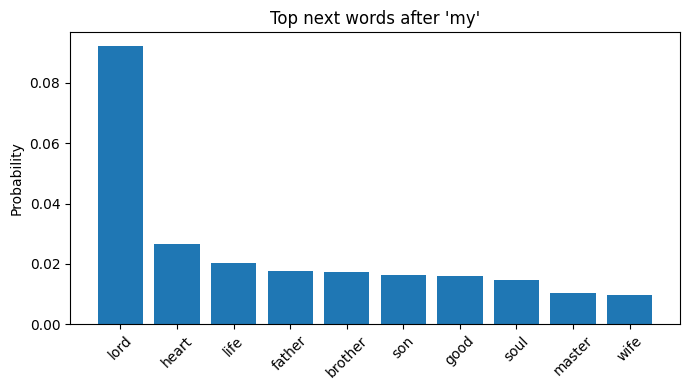

In [7]:
import matplotlib.pyplot as plt

model = MarkovChain(order=1, level="word").train(text)
state = ("my",)
probs = model.next_probs(state)
top = list(probs.items())[:10]

words = [w for w, _ in top]
values = [p for _, p in top]

plt.figure(figsize=(7, 4))
plt.bar(words, values)
plt.title(f"Top next words after '{state[0]}'")
plt.ylabel("Probability")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Observations
- **Low order** gives more random, less coherent text because the model only sees very little context.
- **Higher order** produces more fluent text, but it starts copying long stretches of the training data because most states have only one possible next token.
- A Markov chain has no memory beyond its order, so it cannot keep a topic or plot going. That is the key limit compared with transformers like GPT-2.